In [ ]:
%pip install matplotlib surprise

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.1 MB 16.8 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 19.6 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 15.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 19.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   -------------------------------------- - 6.8/7.0 MB 38.7 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 27.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# EDA
1. Average ratings per user
2. Distribution: are there power users with many ratings
3. Average ratings per item 
4. Explicit or implicit ratings
5. Ratings distribution



In [116]:
path = r'C:\Users\dcheruiyot2\OneDrive - KPMG\Projects\amazon_recsys\dataset\utility\reviews.csv'
df = pd.read_csv(path)

# df.shape
# df.iloc()

# print(list(df.columns))
def initial_eda(df):
    print(f"Df shape: {df.shape}")   
    print(f"Date Types: {df.dtypes}")
    df.head(3)


def missing_cols(df):
    # missing values
    missing = df.isnull().sum()
    missing_pct = (missing/len(df)*100).round(2)
    summary=pd.DataFrame({'missing': missing, 'pct':missing_pct})
    print(summary[summary['missing']>0])

def data_prop(df, user_id, prod_id, rating):
    print(f"Unique users: {df[user_id].nunique()}")
    print(f"Unique products: {df[prod_id].nunique()}")
    print(f"Matrix size: {df[user_id].nunique()*df[prod_id].nunique()}")
    n_rating = df[rating].notna().sum()
    sparsity = (1-n_rating/(df[user_id].nunique()*df[prod_id].nunique()))*100
    print (f'{sparsity.round(4)}% ')


    
initial_eda(df)
missing_cols(df)
data_prop(df,'reviewerID','ASIN', 'customerReview')
df.head(3)

Df shape: (324662, 12)
Date Types: Unnamed: 0          int64
folder_name           str
ASIN                  str
ProductName           str
price             float64
image                 str
reviewerID            str
customerReview    float64
reviewDate            str
reviewLocation        str
reviewVotes         int64
category              str
dtype: object
             missing   pct
ProductName      114  0.04
price          11117  3.42
image            114  0.04
Unique users: 296498
Unique products: 33510
Matrix size: 9935647980
99.9967% 


,Unnamed: 0,folder_name,ASIN,ProductName,price,image,reviewerID,customerReview,reviewDate,reviewLocation,reviewVotes,category
0,0,microwave,b085fzxzj5,toshiba_mlem45pitbs_countertop_microwave_oven_...,169.99,https://images-na.ssl-images-amazon.com/images...,ChrisChris_AERHRY53MCLOIYM2EUPROS7VFBBA,5.0,"September 15, 2020",United States,183,Kitchen
1,1,microwave,b085fzxzj5,toshiba_mlem45pitbs_countertop_microwave_oven_...,169.99,https://images-na.ssl-images-amazon.com/images...,Abby J. _AHYVM23MR42XCBX3U3VPAOJKSYPA,5.0,"December 5, 2020",United States,515,Kitchen
2,2,microwave,b085fzxzj5,toshiba_mlem45pitbs_countertop_microwave_oven_...,169.99,https://images-na.ssl-images-amazon.com/images...,Westman_d5857da1-8118-4b79-a8ec-f8b2a42f1203,5.0,"January 22, 2024",Canada,0,Kitchen


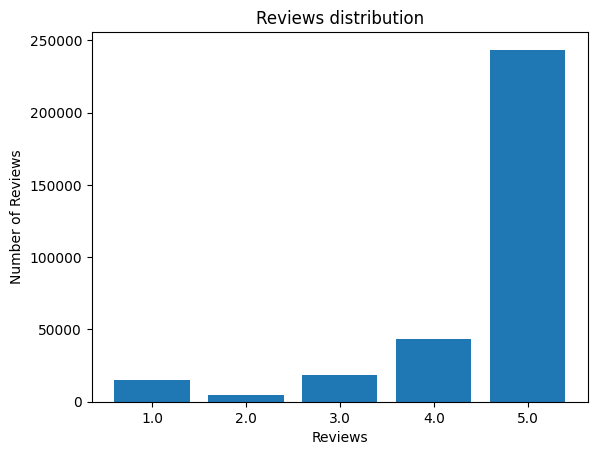

In [82]:
#Reviews distribution
counts=df['customerReview'].dropna().value_counts().sort_index()
counts

fig, ax = plt.subplots()
plt.bar(counts.index.astype(str), counts.values)
ax.set_title('Reviews distribution')
ax.set_xlabel('Reviews')
ax.set_ylabel('Number of Reviews')
plt.show()

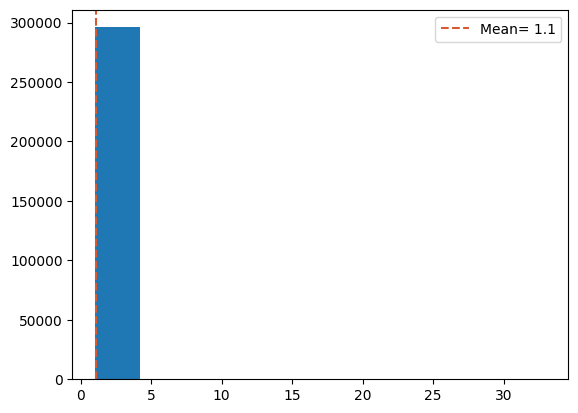

In [89]:
user_count=df.groupby('reviewerID')['customerReview'].count().reset_index()
user_count.columns =['user', 'num_ratings']
reviews_per_user=user_count['num_ratings'].mean()


fig, ax = plt.subplots()
ax.hist(user_count['num_ratings'])
ax.axvline(reviews_per_user,color='#d85a30',linestyle='--', label=f'Mean={reviews_per_user: .1f}')
ax.legend()

plt.show()

count    33510.000000
mean         9.688511
std          3.787007
min          1.000000
25%          8.000000
50%          9.000000
75%         13.000000
max         52.000000
Name: customerReview, dtype: float64
Products with only one rating: 2.28%


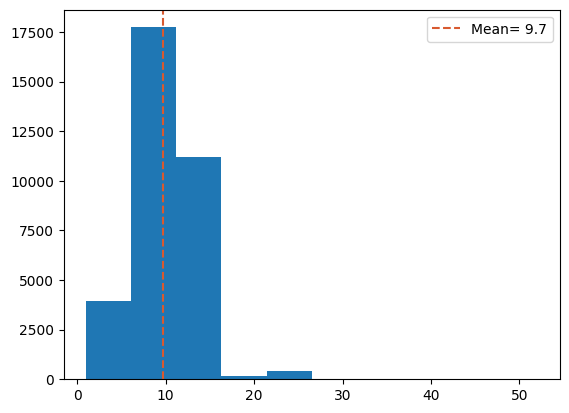

In [98]:
product_count = df.groupby('ASIN')['customerReview'].count().reset_index()
reviews_per_product =product_count['customerReview'].mean()


fig,ax=plt.subplots()
ax.hist(product_count['customerReview'])
ax.axvline(reviews_per_product, color='#d85a30',linestyle='--', label=f'Mean={reviews_per_product: .1f}')
ax.legend()
plt.show

print(product_count['customerReview'].describe())
print(f'Products with only one rating: {(product_count["customerReview"]==1).mean()*100:.2f}%')

# User-Item interaction matrix
rows=users
columns = products
values=ratings
empty cells = what needs to be predicted